In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
import pywt

In [2]:
def extract_wavelet_features(signal, wavelet='db4', level=3):
    features = []

    coeffs = pywt.wavedec(signal, wavelet, level=level)

    # coeffs[0] = aproximação
    # coeffs[1:] = detalhes

    for coeff in coeffs:
        energy = np.sum(coeff**2)
        features.append(energy)

    return features

In [3]:
def extract_features(signal):
    features = []

    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.min(signal))
    features.append(np.max(signal))
    features.append(np.ptp(signal))  # peak-to-peak
    features.append(np.sum(signal**2))  # energia
    features.append(skew(signal))
    features.append(kurtosis(signal))

    peaks, _ = find_peaks(signal)
    features.append(len(peaks))  # número de picos

    features.append(len(signal))  # duração

    return features

In [11]:
def extract_clinical_features(signal, fs=360):
    features = []

    signal = signal.astype(np.float32)

    # ----- Estatísticas -----
    features.extend([
        np.mean(signal),
        np.std(signal),
        np.min(signal),
        np.max(signal),
        np.ptp(signal),
        np.sum(signal**2),
        np.sum(np.abs(signal)),
        skew(signal),
        kurtosis(signal)
    ])

    # ----- Pico R -----
    peaks, _ = find_peaks(signal, distance=50)

    if len(peaks) > 0:
        r_peak_amp = np.max(signal[peaks])
        features.append(r_peak_amp)
    else:
        features.append(0)

    # ----- QRS width -----
    if len(peaks) > 0:
        peak = peaks[np.argmax(signal[peaks])]
        threshold = signal[peak] * 0.5

        left = peak
        while left > 0 and signal[left] > threshold:
            left -= 1

        right = peak
        while right < len(signal)-1 and signal[right] > threshold:
            right += 1

        qrs_width = (right - left) / fs
        features.append(qrs_width)
    else:
        features.append(0)

    # ----- FFT dominante -----
    yf = np.abs(rfft(signal))
    xf = rfftfreq(len(signal), 1/fs)

    dominant_freq = xf[np.argmax(yf)]
    spectral_energy = np.sum(yf)

    features.append(dominant_freq)
    features.append(spectral_energy)

    # ----- WAVELET -----
    wavelet_features = extract_wavelet_features(signal, wavelet='db4', level=4)
    features.extend(wavelet_features)

    return features

In [9]:
def extract_clinical_features(signal, fs=360):
    features = []

    signal = signal.astype(np.float32)

    # --- Estatísticas básicas ---
    mean = np.mean(signal)
    std = np.std(signal)
    minimum = np.min(signal)
    maximum = np.max(signal)
    ptp = np.ptp(signal)
    energy = np.sum(signal**2)
    area = np.sum(np.abs(signal))
    sk = skew(signal)
    kurt = kurtosis(signal)

    features.extend([mean, std, minimum, maximum, ptp, energy, area, sk, kurt])

    # --- Pico R ---
    peaks, properties = find_peaks(signal, distance=50)

    if len(peaks) > 0:
        r_peak_amp = np.max(signal[peaks])
        features.append(r_peak_amp)
    else:
        features.append(0)

    # --- Largura aproximada do QRS ---
    if len(peaks) > 0:
        peak = peaks[np.argmax(signal[peaks])]
        threshold = signal[peak] * 0.5

        left = peak
        while left > 0 and signal[left] > threshold:
            left -= 1

        right = peak
        while right < len(signal)-1 and signal[right] > threshold:
            right += 1

        qrs_width = (right - left) / fs  # em segundos
        features.append(qrs_width)
    else:
        features.append(0)

    # --- FFT ---
    yf = np.abs(rfft(signal))
    xf = rfftfreq(len(signal), 1/fs)

    dominant_freq = xf[np.argmax(yf)]
    spectral_energy = np.sum(yf)

    features.append(dominant_freq)
    features.append(spectral_energy)

    return features

In [12]:
def build_dataset(root_dir):
    X = []
    y = []

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(class_path, file)

            df = pd.read_csv(file_path)

            # Detecta coluna correta
            if "amplitude" in df.columns:
                signal = df["amplitude"].values
            elif "channel_0" in df.columns:
                signal = df["channel_0"].values
            else:
                signal = df.values.flatten()

            signal = signal.astype(np.float32)

            features = extract_clinical_features(signal)

            X.append(features)
            y.append(class_name)

    return np.array(X), np.array(y)

In [13]:
X_train, y_train = build_dataset("dataset_split_2/train")
X_val, y_val = build_dataset("dataset_split_2/val")

print("Features por amostra:", X_train.shape[1])

rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [None, 20, 40, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,           # só 20 combinações
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

Features por amostra: 18
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=60, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=  38.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=  58.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time= 1.1min
[CV] END max_depth=60, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  43.3s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time= 1.0min
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=800; total time= 1.5min
[CV] END max_depth=40, max_features=log2, min_samples_leaf=2, min_samples_s

In [14]:
best_rf = random_search.best_estimator_

y_pred = random_search.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[ 825    1    2    3   18   46    6    1]
 [   2 1184    0    1    1    1    5   18]
 [   6    0  546    4    3    1   48    4]
 [   4    1    4 1173    3    0   26    0]
 [   7    3    2   10 1411    3   45   18]
 [  40    2    0    6    4 1141   32    0]
 [   2   15   49   15   26   16 1049   10]
 [   2   22    2    1    6    0   18  549]]
              precision    recall  f1-score   support

           A       0.93      0.91      0.92       902
           B       0.96      0.98      0.97      1212
           F       0.90      0.89      0.90       612
           L       0.97      0.97      0.97      1211
           N       0.96      0.94      0.95      1499
           R       0.94      0.93      0.94      1225
           V       0.85      0.89      0.87      1182
           f       0.92      0.92      0.92       600

    accuracy                           0.93      8443
   macro avg       0.93      0.93      0.93      8443
weighted avg       0.93      0.93      0.93      8443



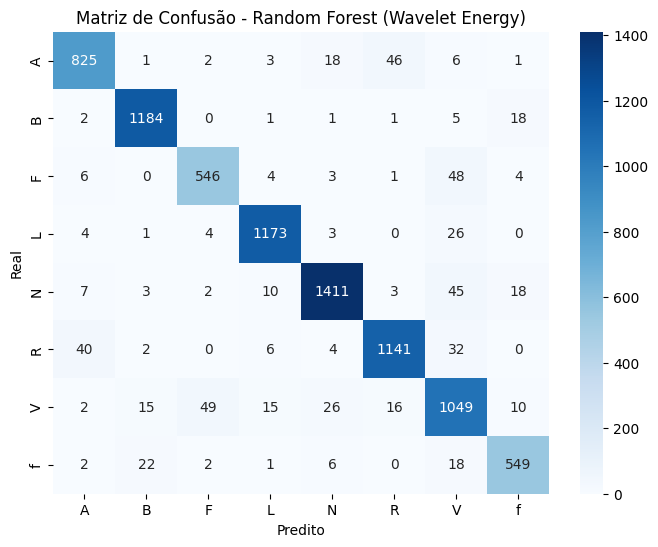

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
labels = random_search.classes_

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest (Wavelet Energy)")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred, digits=4))

              precision    recall  f1-score   support

           A     0.9291    0.9146    0.9218       902
           B     0.9642    0.9769    0.9705      1212
           F     0.9025    0.8922    0.8973       612
           L     0.9670    0.9686    0.9678      1211
           N     0.9586    0.9413    0.9498      1499
           R     0.9445    0.9314    0.9379      1225
           V     0.8535    0.8875    0.8702      1182
           f     0.9150    0.9150    0.9150       600

    accuracy                         0.9331      8443
   macro avg     0.9293    0.9284    0.9288      8443
weighted avg     0.9335    0.9331    0.9332      8443

